## Setting up environment for Colab

In [1]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
import sys
from google.colab import userdata

config_path = userdata.get('CONFIG_PATH')

sys.path.append(config_path)

from config import BASE_PATH, DATA_PATH, SRC_PATH, SAVED_CHECKPOINTS_PATH

## Week 3 — Session 3: Advanced Models AI Pipeline Techniques

In this final session, we will expand our misinformation detection system using more advanced techniques, each tried **independently**.

---

### **Goals**

- Brief Coverage of Hyperparameter Tuning
- Build and evaluate a **voting ensemble** using multiple baseline models.
- Train and test a **transformer-based model** (e.g., BERT) for misinformation classification.
- Experiment with a simple **retrieval component** to check if claims are supported by external information.

---

### **What We Will Do**

- **Ensemble:** Combine classic models like decision trees, random forests, or XGBoost using a voting or weighted scheme.
- **Transformer:** Fine-tune a transformer model to classify news articles.
- **Retrieval:** Add a retrieval step that fetches supporting facts and uses them to inform predictions.

---

### **Key Point**

Each method will be developed and evaluated **separately** — we will not combine the transformer or retrieval with the ensemble. The goal is to understand the strengths and limitations of each approach on its own.

---

### **Outcome**

By the end, we will:
- Know how to create and compare different advanced pipelines.
- Understand how to use transformers for text classification.
- See how retrieval can add factual verification.
- Have the flexibility to mix and match these ideas for your own project later.

## Libraries We'll Use

We'll use a mix of **scikit-learn** tools and **XGBoost** for hyperparameter tuning:

- `XGBClassifier` — the main model we’ll tune.
- `GridSearchCV` — scikit-learn’s tool for **exhaustive grid search**.
- `StratifiedKFold` — to keep class balance during cross-validation.
- `classification_report` & `confusion_matrix` — for evaluating results.
- `seaborn` & `matplotlib` — to visualize the impact of hyperparameters.

---

Make sure you have **`xgboost`** and **`scikit-learn`** installed!

In [3]:
!pip install xgboost scikit-learn matplotlib seaborn sentence-transformers annoy tiktoken

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 36.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=549275 sha256=b9ef6bae405b80b2e32667ac7026fcf06a5dc4140bfe168a6cb35698434518d5
  Stored in directory: /root/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


In [4]:
!pip install {SRC_PATH}

Processing ./drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/src
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 96.7 MB/s eta 0:00:00
  Created wheel for misinformation_detection: filename=misinformation_detection-1.0.0-py3-none-any.whl size=20155 sha256=63b4b20bc32c459fdabc48aea315337e09f1a488b1903c23e3211be19f6fe23c
  Stored in directory: /tmp/pip-ephem-wheel-cache-dyqmr7yt/wheels/46/67/19/6967c24d7ffe355b16d9bd45b2a6576a3fa548c7b58c981aee
Successfully built misinformation_detection


In [5]:
# Ignore ALL warnings globally
import warnings

warnings.filterwarnings("ignore")

## Load and Prepare Data for Hyperparameter Tuning

In this step, we’ll **reuse our previous pipeline** to get our data ready for **hyperparameter search**:

- **Load** the cleaned dataset with lemmatized text.
- **Split** into train/test with stratified sampling.
- Apply **TF-IDF vectorization** on the lemmatized text.
- Combine **TF-IDF features** with our structured features (linguistic & source-based).
- Inspect shapes and columns to confirm our features are ready.

This ensures we have a consistent input for **grid search and random search** with our chosen models (XGBoost in this case).

In [6]:
import sys
import os
from pathlib import Path

from misinformation_detection.data import prepare_text_structured_features_full

X_train_combined, X_test_combined, X_structured_train_full, X_structured_test_full, y_train, y_test, vectorizer = prepare_text_structured_features_full(
    DATA_PATH / Path("processed/fnn_lemmatized.csv")
)

## Sanity Check: Re-run XGBoost with Current Features
Before tuning hyperparameters, it’s good practice to **run our base XGBoost classifier**  
with our combined **TF-IDF + structured features** to:

- Confirm that our pipeline runs end-to-end without errors.
- Get baseline performance metrics (accuracy, precision, recall, F1).
- Inspect the confusion matrix to see where errors occur.
- Visualize top feature importances for interpretability.

This ensures our data split, encodings, and feature engineering are correct before performing **Grid Search** or **Randomized Search** for hyperparameter tuning.

Model loaded from /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/xgboost_model.joblib
Accuracy: 0.8233, Precision: 0.7641, Recall: 0.3385, F1-score: 0.4692


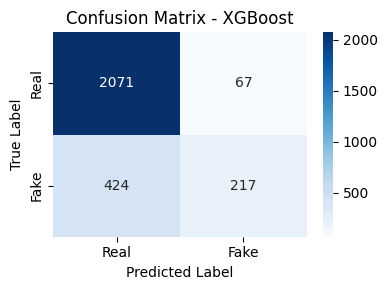

(0.8233177401943145,
 0.7640845070422535,
 0.33853354134165364,
 0.46918918918918917)

In [ ]:
from misinformation_detection.models import XGBoostModel

# Convert labels to numeric: real=0, fake=1
y_train_encoded = y_train.map({"real": 0, "fake": 1})
y_test_encoded = y_test.map({"real": 0, "fake": 1})

# 1. Initialize and train
xgb_clf = XGBoostModel(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

xgb_clf.load_model(SAVED_CHECKPOINTS_PATH / Path("xgboost_model.joblib"))

xgb_clf.evaluate(X_test_combined, y_test_encoded)

param_grid = {
    "max_depth": [3, 5, 7, 10, 12],
    "learning_rate": [0.005, 0.01, 0.05, 0.1, 0.2],
    "n_estimators": [50, 100, 200, 300],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.5, 1.0, 1.5, 2.0]
}

param_grid = {
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [50, 100, 200],
    "subsample": [0.7, 0.8, 1.0]
}

## Grid Search

This cell shows how to **manually implement a grid search** for XGBoost hyperparameters.

---

### **What’s happening?**

1. **Encode labels:**  
   - Split training data into training and validation set

1. **Encode labels:**  
   - Convert `"real"` → `0` and `"fake"` → `1` for compatibility with XGBoost.

1. **Define a parameter grid:**  
   - Try different combinations of `max_depth`, `learning_rate`, `n_estimators`, and `subsample`.

1. **Generate all combinations:**  
   - Uses `itertools.product` to get every possible set of hyperparameters.

1. **Loop over combinations:**  
   - For each, train on the **training set**.
   - Evaluate on the **val set**.
   - Store and print the val accuracy.

1. **Rank results:**  
   - Sort by accuracy and print the top 3 configurations.
   
1. **Test model:**  
   - Now we can finally test our top 3 configurations on our **test set**.

---

**Why do this manually?**  
- Great for understanding how combinatorial search space grows!

In [ ]:
import itertools
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from misinformation_detection.models import XGBoostModel

os.mkdir(SAVED_CHECKPOINTS_PATH / Path("grid_search"))

# Encode labels: 'real' → 0, 'fake' → 1
y_train_encoded = y_train.map({"real": 0, "fake": 1})
y_test_encoded = y_test.map({"real": 0, "fake": 1})


X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_combined,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Define a small parameter grid for demonstration
param_grid = {
    "max_depth": [3, 5, 7],       # How deep the trees can grow
    "learning_rate": [0.01, 0.1], # Step size shrinkage
    "n_estimators": [25, 50, 100],  # Number of boosting rounds
    "subsample": [0.6, 0.8, 1.0],        # Fraction of samples per tree
}

# Generate all possible combinations of hyperparameters
keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
print(f"Total combinations: {len(param_combinations)}")

results = []

# Loop over each parameter combination
for params, i in zip(param_combinations, range(len(param_combinations))):
    # Initialize XGBoost classifier with current params
    xgb_clf = XGBoostModel(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        **params
    )

    # Train on full training data
    xgb_clf.fit(X_train_split, y_train_split)

    acc, precision, recall, f1 = xgb_clf.evaluate(X_val_split, y_val_split, verbose=False)

    # Store result
    results.append((i, params, acc))
    xgb_clf.save_model(SAVED_CHECKPOINTS_PATH / Path(f"grid_search/xgb_{i}.joblib"))
    print(f"Params: {params} | Val Accuracy: {acc:.4f}")

# Sort results by accuracy descending
results.sort(key=lambda x: x[2], reverse=True)




Total combinations: 54
Model saved to /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/grid_search/xgb_0.joblib
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 25, 'subsample': 0.6} | Val Accuracy: 0.7692
Model saved to /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/grid_search/xgb_1.joblib
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 25, 'subsample': 0.8} | Val Accuracy: 0.7692
Model saved to /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/grid_search/xgb_2.joblib
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 25, 'subsample': 1.0} | Val Accuracy: 0.7692
Model saved to /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/grid_search/xgb_3.joblib
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 50, 'subsample': 0.6} | Val Accuracy: 0.7692
Model saved to /c

In [ ]:

# Show top 3 parameter sets
print("\nTop parameter sets:")
for i, params, score in results[:3]:
    xgb_clf = XGBoostModel(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        **params
    )
    xgb_clf.load_model(SAVED_CHECKPOINTS_PATH / Path(f"grid_search/xgb_{i}.joblib"))
    acc, precision, recall, f1 = xgb_clf.evaluate(X_test_combined, y_test_encoded, verbose=False)
    print(f"Val Accuracy: {score:.4f} | Params: {params}")
    print(f"Train Accuracy: {score:.4f} | Params: {params}")


Top parameter sets:
Model loaded from /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/grid_search/xgb_48.joblib
Val Accuracy: 0.8241 | Params: {'max_depth': 7, 'learning_rate': 0.1, 'n_estimators': 50, 'subsample': 0.6}
Train Accuracy: 0.8241 | Params: {'max_depth': 7, 'learning_rate': 0.1, 'n_estimators': 50, 'subsample': 0.6}
Model loaded from /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/grid_search/xgb_33.joblib
Val Accuracy: 0.8223 | Params: {'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.6}
Train Accuracy: 0.8223 | Params: {'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.6}
Model loaded from /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/grid_search/xgb_51.joblib
Val Accuracy: 0.8223 | Params: {'max_depth': 7, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.6}
Train Accuracy: 0.8223 | Pa

## Random Search for XGBoost Hyperparameter Tuning

Random Search samples random combinations of hyperparameters within defined ranges for XGBoost models, trading exhaustive coverage for computational efficiency. This method can discover good configurations faster by randomly exploring the search space.

The steps are:
- Define hyperparameter ranges.
- Randomly sample parameter sets.
- Train and evaluate XGBoost models for each sampled set on the training and test datasets.


In [ ]:
import random

# Hyperparameter space (same as grid search)
param_space = {
    "max_depth": [3, 5, 7],          # Tree depth
    "learning_rate": [0.01, 0.1],    # Step size shrinkage
    "n_estimators": [25, 50, 100, 150], # Boosting rounds
    "subsample": [0.6, 0.8, 1.0]     # Sample fraction per tree
}

def sample_random_params(param_space, n_samples=10):
    keys = list(param_space.keys())
    samples = []
    for _ in range(n_samples):
        sample = {k: random.choice(param_space[k]) for k in keys}
        samples.append(sample)
    return samples

random_params_samples = sample_random_params(param_space, n_samples=10)
print(f"Random parameter combinations (10 samples): {random_params_samples}")


Random parameter combinations (10 samples): [{'max_depth': 7, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 1.0}, {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 50, 'subsample': 0.6}, {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 50, 'subsample': 0.6}, {'max_depth': 7, 'learning_rate': 0.01, 'n_estimators': 150, 'subsample': 0.8}, {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 50, 'subsample': 0.8}, {'max_depth': 5, 'learning_rate': 0.01, 'n_estimators': 150, 'subsample': 1.0}, {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 150, 'subsample': 0.8}, {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 50, 'subsample': 0.6}, {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 150, 'subsample': 1.0}, {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 150, 'subsample': 0.6}]


In [ ]:
results_random = []
os.mkdir(SAVED_CHECKPOINTS_PATH / Path("random_search"))


for i, params in enumerate(random_params_samples):
    print(f"Trial {i+1}/{len(random_params_samples)}, Params: {params}")
    xgb_model = XGBoostModel(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        **params
    )
    # Train on training split
    xgb_model.fit(X_train_split, y_train_split)

    # Evaluate on validation split
    acc, precision, recall, f1 = xgb_model.evaluate(X_val_split, y_val_split, verbose=False)

    print(f"Validation Accuracy: {acc:.4f}")
    results_random.append((i, params, acc))

    # Optionally save model checkpoint
    xgb_model.save_model(SAVED_CHECKPOINTS_PATH / Path(f"random_search/xgb_{i}.joblib"))

# Sort results by validation accuracy in descending order
results_random.sort(key=lambda x: x[2], reverse=True)
print(f"\nTop random search hyperparameter set:\nIndex: {results_random[0][0]}, Params: {results_random[0][1]}, Accuracy: {results_random[0][2]:.4f}")


Trial 1/10, Params: {'max_depth': 7, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 1.0}
Validation Accuracy: 0.8133
Model saved to /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/random_search/xgb_0.joblib
Trial 2/10, Params: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 50, 'subsample': 0.6}
Validation Accuracy: 0.8138
Model saved to /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/random_search/xgb_1.joblib
Trial 3/10, Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 50, 'subsample': 0.6}
Validation Accuracy: 0.7692
Model saved to /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/random_search/xgb_2.joblib
Trial 4/10, Params: {'max_depth': 7, 'learning_rate': 0.01, 'n_estimators': 150, 'subsample': 0.8}
Validation Accuracy: 0.8138
Model saved to /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_ch

In [ ]:

# Show top 3 parameter sets
print("\nTop parameter sets:")
for i, params, score in results_random[:3]:
    xgb_clf = XGBoostModel(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        **params
    )
    xgb_clf.load_model(SAVED_CHECKPOINTS_PATH / Path(f"random_search/xgb_{i}.joblib"))
    acc, precision, recall, f1 = xgb_clf.evaluate(X_test_combined, y_test_encoded, verbose=False)
    print(f"Val Accuracy: {score:.4f} | Params: {params}")
    print(f"Train Accuracy: {score:.4f} | Params: {params}")


Top parameter sets:
Model loaded from /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/random_search/xgb_8.joblib
Val Accuracy: 0.8187 | Params: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 150, 'subsample': 1.0}
Train Accuracy: 0.8187 | Params: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 150, 'subsample': 1.0}
Model loaded from /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/random_search/xgb_6.joblib
Val Accuracy: 0.8178 | Params: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 150, 'subsample': 0.8}
Train Accuracy: 0.8178 | Params: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 150, 'subsample': 0.8}
Model loaded from /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/random_search/xgb_4.joblib
Val Accuracy: 0.8147 | Params: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 50, 'subsample': 0.8}
Train Accuracy: 0.8147 

## What Is an Ensemble Classifier?

In this part, we will build a **simple ensemble classifier** for misinformation detection.

---

### Why Use Ensembles?

- Combines the strengths of multiple models.
- Reduces the risk of relying on one model’s weaknesses.
- Often improves accuracy and generalization.

---

### How Does It Work?

- Each base model makes its own prediction (e.g., real or fake).
- The ensemble aggregates these predictions using **voting**.
- The final output is based on this combined decision.

---

### Hard Voting vs. Soft Voting

- **Hard Voting:** Uses the majority class label predicted by each model.
- **Soft Voting:** Averages the predicted probabilities, then picks the class with the highest average probability.

---

### What Will We Do?

- Train multiple base models you have seen so far.
- Combine them into a simple voting ensemble.
- Evaluate ensemble performance vs. individual models.

We will **also train a transformer-based classifier** and a **retrieval-based classifier**, but these will be tested **separately** — **not as part of the ensemble**.

---

**Key takeaway:** A well-designed ensemble can often outperform any single model and provide more robust predictions.

In [ ]:
from misinformation_detection.data import prepare_text_structured_features_full

X_train_combined, X_test_combined, X_structured_train_full, X_structured_test_full, y_train, y_test, vectorizer = prepare_text_structured_features_full(
    DATA_PATH / Path("processed/fnn_lemmatized.csv")
)

## Hard Voting Ensemble: How It Works

In this demonstration, we built a **hard voting ensemble** for misinformation detection using three different classifiers:

- **Decision Tree**
- **Random Forest**
- **XGBoost**

---

### **What is Hard Voting?**

- Each base model makes a **class prediction** (real or fake).
- For each sample, the predictions from all models are collected.
- The final prediction is the **majority vote** — the class that appears most often.
- With an **odd number** of classifiers (3 in this case), ties are impossible.

---

### **What We Did**

1. **Trained 3 separate models** on the same training data.
2. Calculated and printed their **individual test accuracies**.
3. Stacked their predictions and applied **manual majority voting**:
   - For each example, the final prediction is the class predicted by at least 2 out of 3 models.

4. Compared the **ensemble accuracy** to the individual model accuracies.

---

**Key takeaway:**  
A simple hard voting ensemble can boost robustness and accuracy by combining the strengths of multiple models and reducing the risk of any single weak model.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Encode labels: real=0, fake=1
y_train_encoded = y_train.map({"real": 0, "fake": 1})
y_test_encoded = y_test.map({"real": 0, "fake": 1})

# === Train Decision Tree ===
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train_combined, y_train_encoded)
tree_preds = tree_clf.predict(X_test_combined)
tree_acc = accuracy_score(y_test_encoded, tree_preds)
print(f"Decision Tree Test Accuracy: {tree_acc:.4f}")

# === Train Random Forest ===
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_combined, y_train_encoded)
rf_preds = rf_clf.predict(X_test_combined)
rf_acc = accuracy_score(y_test_encoded, rf_preds)
print(f"Random Forest Test Accuracy: {rf_acc:.4f}")

# === Train XGBoost ===
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_clf.fit(X_train_combined, y_train_encoded)
xgb_preds = xgb_clf.predict(X_test_combined)
xgb_acc = accuracy_score(y_test_encoded, xgb_preds)
print(f"XGBoost Test Accuracy: {xgb_acc:.4f}")

# === Manually do majority vote ===
all_preds = np.vstack([tree_preds, rf_preds, xgb_preds])
ensemble_preds = np.round(all_preds.mean(axis=0)).astype(int)
ensemble_acc = accuracy_score(y_test_encoded, ensemble_preds)
print(f"Ensemble Test Accuracy: {ensemble_acc:.4f}")

Decision Tree Test Accuracy: 0.8057
Random Forest Test Accuracy: 0.8222
XGBoost Test Accuracy: 0.8194
Ensemble Test Accuracy: 0.8222


## Soft Voting Ensemble: How It Works

In this demonstration, we built a **soft voting ensemble** for misinformation detection using the same three classifiers:

- **Decision Tree**
- **Random Forest**
- **XGBoost**

---

### **What is Soft Voting?**

- Each base model predicts a **probability** for each class instead of a hard label.
- For each test sample, we **average the predicted probabilities** for the positive class (**fake**).
- The final prediction is `1` (**fake**) if the average probability ≥ 0.5; otherwise, it’s `0` (**real**).

---

### **What We Did**

1. **Trained 3 separate models** on the same training data.
2. Calculated and printed their **individual test accuracies**.
3. Collected each model’s **probabilities** for the test set.
4. Averaged the probabilities across all models and applied a **0.5 threshold** to make the final prediction.
5. Compared the **ensemble accuracy** to the individual model accuracies.

---

**Key takeaway:**  
**Soft voting** considers how confident each model is in its prediction, which can lead to smoother and more robust ensemble performance compared to simple hard voting.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Encode labels: real=0, fake=1
y_train_encoded = y_train.map({"real": 0, "fake": 1})
y_test_encoded = y_test.map({"real": 0, "fake": 1})

# === Train Decision Tree ===
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train_combined, y_train_encoded)
tree_probs = tree_clf.predict_proba(X_test_combined)[:, 1]  # Probability for class 1
tree_acc = accuracy_score(y_test_encoded, tree_clf.predict(X_test_combined))
print(f"Decision Tree Test Accuracy: {tree_acc:.4f}")

# === Train Random Forest ===
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_combined, y_train_encoded)
rf_probs = rf_clf.predict_proba(X_test_combined)[:, 1]
rf_acc = accuracy_score(y_test_encoded, rf_clf.predict(X_test_combined))
print(f"Random Forest Test Accuracy: {rf_acc:.4f}")

# === Train XGBoost ===
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_clf.fit(X_train_combined, y_train_encoded)
xgb_probs = xgb_clf.predict_proba(X_test_combined)[:, 1]
xgb_acc = accuracy_score(y_test_encoded, xgb_clf.predict(X_test_combined))
print(f"XGBoost Test Accuracy: {xgb_acc:.4f}")

# === Soft Voting ===
# Average predicted probabilities
avg_probs = (tree_probs + rf_probs + xgb_probs) / 3

# Final prediction: threshold at 0.5
ensemble_preds = (avg_probs >= 0.5).astype(int)

ensemble_acc = accuracy_score(y_test_encoded, ensemble_preds)
print(f"Soft Voting Ensemble Test Accuracy: {ensemble_acc:.4f}")

Decision Tree Test Accuracy: 0.8057
Random Forest Test Accuracy: 0.8222
XGBoost Test Accuracy: 0.8194
Soft Voting Ensemble Test Accuracy: 0.8186


## Fact-Augmented Classification with DistilBert + RAG

We now move beyond using just the article text. In this section, we **enrich each article with top retrieved facts** from Wikipedia using our custom RAG (Retrieval-Augmented Generation) system. The retrieved fact chunks are **prepended** to the article content to serve as **contextual evidence** for better classification.

---

### Retrieval System Overview

We’ve built a RAG system backed by:

- **Azure OpenAI embeddings** (`text-embedding-3-large`)
- **Annoy index** for fast approximate nearest neighbor search
- **Cleaned Wikipedia dump** chunked into overlapping 256-token segments

This system returns the most semantically similar factual chunks for any input article.

---

### Classification Workflow

For each news article:

1. **Retrieve Top-K Fact Chunks** using its cleaned article text.
2. **Concatenate Facts + Article** into a single input sequence.
3. **Pass Through Frozen DistilBert Encoder**, using only the `[CLS]` token to summarize the fact-aware input.
4. Feed `[CLS]` into an **MLP classifier** for binary classification.

**Input Format**:
    [CLS] fact_1 [SEP] article_text [SEP]

### Why This Matters

- Adds **factual grounding** to the model input, mimicking a real-world fact-checking process.
- Allows the model to catch hallucinations or unsupported claims more effectively.
- Only the classifier head is trained; the encoder remains frozen for efficiency.

This setup will serve as our **final and most advanced architecture** before exploring LLM approaches.

In [8]:
import json
from annoy import AnnoyIndex
from sentence_transformers import SentenceTransformer
from pathlib import Path
import torch

# --- LOCAL RAG CONFIG ---
EMBED_DIM = 384  # Dimension for all-MiniLM-L6-v2
NEW_INDEX_PATH = DATA_PATH / Path("wikipedia/local_wiki_index.ann")
METADATA_PATH = DATA_PATH / Path("wikipedia/clean_wiki_metadata.json")
TOP_K = 1

# 1. Load the local embedding model (for retrieval)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embed_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# 2. Load the index and metadata
retrieval_index = AnnoyIndex(EMBED_DIM, 'angular')
retrieval_index.load(str(NEW_INDEX_PATH))

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    retrieval_metadata = json.load(f)

# 3. Helper: Retrieve Fact locally
def retrieve_fact_local(article_text):
    # Use the local model to get the query vector
    query_vector = embed_model.encode(article_text, convert_to_numpy=True)
    nearest_ids = retrieval_index.get_nns_by_vector(query_vector, TOP_K)
    return retrieval_metadata[nearest_ids[0]]["chunk_text"]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Custom Dataset with On-the-Fly RAG Retrieval

This dataset class (`RAGFNNDataset`) extends PyTorch's `Dataset` to support **retrieval-augmented classification** by retrieving a relevant fact for each article dynamically during data loading.

#### Key Features:
- **Dynamic Fact Retrieval**:  
  Uses the `retrieve_fact(article)` function inside `__getitem__()` to fetch a relevant Wikipedia chunk for each article at runtime.
  
- **Input Construction**:  
  Each input consists of: [FACT (256 tokens)] + [SEP] + [ARTICLE (256 tokens)] ensuring a total sequence length of 512 tokens suitable for `roberta-base`.

- **Tokenization**:  
The combined sequence is tokenized using Hugging Face's `DistilBert tokenizer`, with padding and truncation applied to match the model's input size constraints.

- **Returned Format**:  
Each item is a dictionary with:
- `input_ids`
- `attention_mask`
- `labels`

This setup allows retrieval-augmented examples to be generated at runtime, making the training process more dynamic and context-aware.


In [9]:
from torch.utils.data import Dataset

class RAGDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        article = self.texts[idx]
        label = self.labels[idx]

        # 1. Retrieve the fact locally
        fact = retrieve_fact_local(article)

        # 2. Format: [Fact] [SEP] [Article]
        # DistilBert uses [SEP] to separate segments
        combined_text = f"{fact} {self.tokenizer.sep_token} {article}"

        # 3. Tokenize
        encoding = self.tokenizer(
            combined_text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [11]:
from sklearn.model_selection import train_test_split
import pandas as pd
from torch.utils.data import DataLoader
from misinformation_detection.models import DistilBERTModelWrapper


fnn_df = pd.read_csv(DATA_PATH / Path("processed/fnn_cleaned.csv"))

# Encode labels (0: fake, 1: real)
fnn_df["label_enc"] = fnn_df["label"].map({"fake": 0, "real": 1})

# Split into train, val, test (80%, 10%, 10%)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    fnn_df["article_cleaned"].tolist(), fnn_df["label_enc"].tolist(),
    test_size=0.2, stratify=fnn_df["label_enc"], random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.5, stratify=temp_labels, random_state=42
)



# 1. Initialize your existing Wrapper
wrapper = DistilBERTModelWrapper(device=device)

# 2. Prepare your Data (Assuming train_texts and train_labels are defined)
# We create the RAGDataset which will use our local retrieval
train_rag_ds = RAGDataset(train_texts, train_labels, wrapper.tokenizer)
val_rag_ds = RAGDataset(val_texts, val_labels, wrapper.tokenizer)
test_rag_ds = RAGDataset(test_texts, val_labels, wrapper.tokenizer)

# 3. Create DataLoaders
train_loader = DataLoader(train_rag_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_rag_ds, batch_size=16)
test_loader = DataLoader(test_rag_ds, batch_size=16)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:

# 4. Train using your wrapper's existing logic
wrapper.train(train_loader, val_loader, epochs=3)

# 5. Save the final model
wrapper.save(SAVED_CHECKPOINTS_PATH / "distilbert_rag_local.pt")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1: 100%|██████████| 695/695 [06:37<00:00,  1.75it/s]


Eval — Loss: 0.5327, Accuracy: 0.7696, Precision: 0.7696, Recall: 1.0000, F1: 0.8698
Epoch 1: Train loss = 0.5538, Val loss = 0.5327, Val acc = 0.7696


Epoch 2: 100%|██████████| 695/695 [06:42<00:00,  1.73it/s]


Eval — Loss: 0.5230, Accuracy: 0.7696, Precision: 0.7696, Recall: 1.0000, F1: 0.8698
Epoch 2: Train loss = 0.5314, Val loss = 0.5230, Val acc = 0.7696


Epoch 3: 100%|██████████| 695/695 [06:07<00:00,  1.89it/s]


Eval — Loss: 0.5108, Accuracy: 0.7696, Precision: 0.7696, Recall: 1.0000, F1: 0.8698
Epoch 3: Train loss = 0.5215, Val loss = 0.5108, Val acc = 0.7696
Model saved to /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/distilbert_rag_local.pt


In [13]:
wrapper.load(SAVED_CHECKPOINTS_PATH / "distilbert_rag_local.pt")

Model loaded from /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/distilbert_rag_local.pt


In [15]:
wrapper.evaluate(test_loader)

Eval — Loss: 0.5443, Accuracy: 0.7696, Precision: 0.7696, Recall: 1.0000, F1: 0.8698


(0.5442555084310728,
 {'accuracy': 0.769618430525558,
  'precision': 0.769618430525558,
  'recall': 1.0,
  'f1': 0.869812855980472})

In [24]:
import numpy as np

def visualize_rag_retrieval(sample_article, top_n=3):
    """
    Demonstrates how RAG finds factual context for a given article.
    """
    print("="*80)
    print(f"INPUT ARTICLE PREVIEW:\n{sample_article[:200]}...")
    print("="*80)

    # 1. Vectorize the input article (Semantic Encoding)
    # This turns your text into a 384-dimensional coordinate
    query_vector = embed_model.encode(sample_article, convert_to_numpy=True)

    # 2. Search the ANN Index
    # We retrieve the Top N nearest neighbors (IDs)
    nearest_ids, distances = retrieval_index.get_nns_by_vector(
        query_vector,
        top_n,
        include_distances=True
    )

    print(f"\n[RAG] Found {top_n} nearest factual chunks in Wikipedia index:\n")

    for i, (idx, dist) in enumerate(zip(nearest_ids, distances)):
        # 3. Pull the text from the JSON Metadata
        fact_text = retrieval_metadata[idx]['chunk_text']
        source_title = retrieval_metadata[idx].get('title', 'Unknown Source')

        # Distance: Lower is "closer" or more semantically similar
        print(f"RANK {i+1} (Distance: {dist:.4f})")
        print(f"SOURCE: {source_title}")
        print(f"FACT CHUNK: {fact_text}\n")
        print("-" * 40)

# --- TEST IT OUT ---
# Pick a sample from your training data or write a custom sentence
test_article = train_texts[0]
visualize_rag_retrieval(test_article, top_n=3)

INPUT ARTICLE PREVIEW:
it s bad enough when you re out and about and you see someone wearing your exact outfit, but when you re famous and your accidental twinning goes viral on the internet, that s when you know things are...

[RAG] Found 3 nearest factual chunks in Wikipedia index:

RANK 1 (Distance: 1.0860)
SOURCE: Al Franken
FACT CHUNK:  longer apology, which Tweeden accepted.
In the days that followed, seven additional women came forward with allegations of inappropriate behavior during photo ops. Lindsay Menz accused Franken of touching her clothed "upper" buttocks while they posed for a photo at the Minnesota State Fair in 2010. Two anonymous women made similar complaints related to events during political events. Franken apologized, saying, "I've met tens of thousands of people and taken thousands of photographs, often in crowded and chaotic situations. I'm a warm person; I hug people. I've learned from recent stories that in some of those encounters, I crossed a line for some 